# Notebook 3 — Génération du Biais Inductif

**Objectif :** Fusionner les 8 métriques IQA du Notebook 2 en un **score unique $c \in [0, 1]$**
interprétable par le cVAE (1 = très bonne qualité, 0 = image très dégradée).

**Trois méthodes disponibles** (sélectionnées via `APPROACH` dans `pipeline_config.py`) :

| Méthode | Principe | Avantage |
|---|---|---|
| **A — Score pondéré** | Combinaison linéaire de features normalisées, poids = loadings PCA | Interprétable physiquement, poids objectifs |
| **B — PCA (PC1)** | Premier composant principal = direction de variance maximale | Objectif, pas de choix arbitraire |
| **C — Score appris** | MLP entraîné sur features ResNet-18, supervision par dégradations synthétiques | Exploite une représentation apprise, pas seulement linéaire |

**Livrable :** `outputs_theophile/03_Inductive_Bias_Generation/labels_quality.csv` — pont vers le cVAE (Notebooks 4 & 5).

## 0. Configuration

In [1]:
from pathlib import Path
from pipeline_config import APPROACH, get_approach_config, get_score_column, use_resnet, print_approach_summary

# ── Approche sélectionnée ──
print_approach_summary()
USE_RESNET = use_resnet()

# Dossier de sortie — sous-dossiers par approche pour ne jamais mélanger les figures
# spécifiques à une méthode avec les comparaisons communes.
OUTPUT_DIR     = Path("outputs_theophile/03_Inductive_Bias_Generation")
COMMON_DIR     = OUTPUT_DIR / "common"
APPROACH_A_DIR = OUTPUT_DIR / "approach_A_weighted_pca"
APPROACH_B_DIR = OUTPUT_DIR / "approach_B_pca1"
APPROACH_C_DIR = OUTPUT_DIR / "approach_C_learned"
for _d in [OUTPUT_DIR, COMMON_DIR, APPROACH_A_DIR, APPROACH_B_DIR, APPROACH_C_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# Dossier de l'approche active : toute sortie dont le contenu dépend de
# `quality_score`/`quality_label` (donc de APPROACH) doit aller ici, jamais dans
# COMMON_DIR — sinon elle est silencieusement écrasée par le run suivant.
APPROACH_DIRS = {"A": APPROACH_A_DIR, "B": APPROACH_B_DIR, "C": APPROACH_C_DIR}
CURRENT_APPROACH_DIR = APPROACH_DIRS[APPROACH]

# Entrées (produites par le Notebook 2)
NB02_DIR       = Path("outputs_theophile/02_IQA_Metrics_Extraction")
CSV_METRICS    = NB02_DIR / "metrics" / "patch_metrics_full.csv"
RESNET_NPY     = NB02_DIR / "resnet_features" / "resnet18_features.npy"
RESNET_IDS_CSV = NB02_DIR / "resnet_features" / "resnet18_ids.csv"
QMAPS_DIR      = NB02_DIR / "quality_maps"

# Sortie principale (racine — pont vers NB4, partagée par les 3 approches)
OUT_LABELS_CSV = OUTPUT_DIR / "labels_quality.csv"
# Copie figée par approche (traçabilité : permet de relire les quality_score/quality_label
# tels que produits par CETTE approche, même après que d'autres approches aient tourné
# et écrasé OUT_LABELS_CSV)
OUT_LABELS_CSV_APPROACH = CURRENT_APPROACH_DIR / "labels_quality.csv"

print(f"Entrée métriques : {CSV_METRICS}")
print(f"Sortie labels    : {OUT_LABELS_CSV}")
print(f"Sortie labels (copie figée approche {APPROACH}) : {OUT_LABELS_CSV_APPROACH}")

╔══════════════════════════════════════════════════════════╗
║  Approche : A — Score pondéré (poids PCA)                   ║
╚══════════════════════════════════════════════════════════╝
  Colonne de score : score_weighted
  Combinaison linéaire de 6 métriques IQA normalisées Min-Max, pondérées par les loadings absolus du PC1 (|loading| / Σ|loading|, fittés sur TRAIN). Poids objectifs et reproductibles, plus de valeurs manuelles arbitraires.

Entrée métriques : outputs_theophile/02_IQA_Metrics_Extraction/metrics/patch_metrics_full.csv
Sortie labels    : outputs_theophile/03_Inductive_Bias_Generation/labels_quality.csv
Sortie labels (copie figée approche A) : outputs_theophile/03_Inductive_Bias_Generation/approach_A_weighted_pca/labels_quality.csv


## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models
import torchvision.transforms.functional as TVF
import cv2
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

print("Imports OK")

Imports OK


/home/infres/nadiedjoa-24/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Chargement des métriques (sortie Notebook 2)

In [3]:
df_raw = pd.read_csv(CSV_METRICS)

# Identifier le split train/val à partir du chemin de l'image
# seg_train → "train", seg_val → "val"
def _get_split(path_str: str) -> str:
    if "seg_train" in str(path_str):
        return "train"
    elif "seg_val" in str(path_str):
        return "val"
    return "unknown"

df_raw["split"] = df_raw["path"].apply(_get_split)

print(f"Dataset chargé : {len(df_raw)} lignes, {len(df_raw.columns)} colonnes")
print(f"Split : {df_raw['split'].value_counts().to_dict()}")
print(f"Colonnes disponibles :\n{list(df_raw.columns)}")

Dataset chargé : 1200 lignes, 36 colonnes
Split : {'train': 1000, 'val': 200}
Colonnes disponibles :
['image_id', 'path', 'n_valid_patches', 'laplacian_var_mean', 'laplacian_var_std', 'laplacian_var_max', 'laplacian_var_min', 'rms_contrast_mean', 'rms_contrast_std', 'rms_contrast_max', 'rms_contrast_min', 'entropy_mean', 'entropy_std', 'entropy_max', 'entropy_min', 'tenengrad_mean', 'tenengrad_std', 'tenengrad_max', 'tenengrad_min', 'ten_H_mean', 'ten_H_std', 'ten_H_max', 'ten_H_min', 'ten_V_mean', 'ten_V_std', 'ten_V_max', 'ten_V_min', 'ten_D1_mean', 'ten_D1_std', 'ten_D1_max', 'ten_D1_min', 'ten_D2_mean', 'ten_D2_std', 'ten_D2_max', 'ten_D2_min', 'split']


## 3. Nettoyage et inspection

In [4]:
# Colonnes de métriques par suffixe
MEAN_COLS = [c for c in df_raw.columns if c.endswith("_mean")]
STD_COLS  = [c for c in df_raw.columns if c.endswith("_std")]
MAX_COLS  = [c for c in df_raw.columns if c.endswith("_max")]
MIN_COLS  = [c for c in df_raw.columns if c.endswith("_min")]

print(f"Métriques (_mean) : {MEAN_COLS}")
print(f"Métriques (_max)  : {MAX_COLS}")
print(f"Métriques (_min)  : {MIN_COLS}")
print()
print(df_raw[MEAN_COLS].isna().sum())

# Suppression des lignes avec erreurs de traitement
n_before = len(df_raw)
df = df_raw.dropna(subset=MEAN_COLS).copy().reset_index(drop=True)
print(f"\nImages conservées : {len(df)} / {n_before}  ({n_before - len(df)} supprimées)")

Métriques (_mean) : ['laplacian_var_mean', 'rms_contrast_mean', 'entropy_mean', 'tenengrad_mean', 'ten_H_mean', 'ten_V_mean', 'ten_D1_mean', 'ten_D2_mean']
Métriques (_max)  : ['laplacian_var_max', 'rms_contrast_max', 'entropy_max', 'tenengrad_max', 'ten_H_max', 'ten_V_max', 'ten_D1_max', 'ten_D2_max']
Métriques (_min)  : ['laplacian_var_min', 'rms_contrast_min', 'entropy_min', 'tenengrad_min', 'ten_H_min', 'ten_V_min', 'ten_D1_min', 'ten_D2_min']

laplacian_var_mean    0
rms_contrast_mean     0
entropy_mean          0
tenengrad_mean        0
ten_H_mean            0
ten_V_mean            0
ten_D1_mean           0
ten_D2_mean           0
dtype: int64

Images conservées : 1200 / 1200  (0 supprimées)


In [5]:
# Inspection des outliers (> 3σ)
print("Outliers (> 3σ) par métrique :")
for col in MEAN_COLS + MAX_COLS + MIN_COLS:
    z = np.abs((df[col] - df[col].mean()) / df[col].std())
    n_out = (z > 3).sum()
    if n_out > 0:
        print(f"  {col:30s} → {n_out} outliers")

# On garde les outliers : ils représentent les images vraiment dégradées
# que l'on veut distinguer. On les clippe à 1er/99e percentile pour
# ne pas perturber la normalisation Min-Max.
# ⚠ Anti-leakage : percentiles calculés uniquement sur TRAIN
df_clipped = df.copy()
train_mask = df["split"] == "train"
for col in MEAN_COLS + MAX_COLS + MIN_COLS:
    lo, hi = df.loc[train_mask, col].quantile(0.01), df.loc[train_mask, col].quantile(0.99)
    df_clipped[col] = df[col].clip(lo, hi)

print("\nClipping [1%, 99%] appliqué (percentiles calculés sur TRAIN uniquement).")

Outliers (> 3σ) par métrique :
  laplacian_var_mean             → 3 outliers
  rms_contrast_mean              → 1 outliers
  entropy_mean                   → 39 outliers
  tenengrad_mean                 → 1 outliers
  ten_H_mean                     → 2 outliers
  ten_V_mean                     → 1 outliers
  ten_D1_mean                    → 2 outliers
  ten_D2_mean                    → 2 outliers
  laplacian_var_max              → 4 outliers
  rms_contrast_max               → 2 outliers
  entropy_max                    → 21 outliers
  tenengrad_max                  → 7 outliers
  ten_H_max                      → 11 outliers
  ten_V_max                      → 6 outliers
  ten_D1_max                     → 8 outliers
  ten_D2_max                     → 7 outliers
  laplacian_var_min              → 6 outliers
  rms_contrast_min               → 3 outliers
  entropy_min                    → 43 outliers
  tenengrad_min                  → 2 outliers
  ten_H_min                      → 3 outliers

## 4. Feature Engineering : deux indicateurs spatiaux

Les colonnes `*_std` du Notebook 2 encodent la **dispersion spatiale** de chaque métrique à travers les patchs.  
On en dérive deux indicateurs supplémentaires :

| Feature engineerée | Définition | Interprétation |
|---|---|---|
| `spatial_homogeneity` | $1 - \sigma_{\text{tenengrad}} / (\mu_{\text{tenengrad}} + \varepsilon)$ | 1 = qualité uniforme, 0 = zones floues locales |
| `directional_balance` | $\min(H, V, D_1, D_2) / (\max(H, V, D_1, D_2) + \varepsilon)$ | 1 = isotrope, 0 = flou directionnel (mouvement) |

In [6]:
EPS = 1e-8

# spatial_homogeneity : coefficient de variation inversé du tenengrad par patch
df_clipped["spatial_homogeneity"] = (
    1.0 - df_clipped["tenengrad_std"] / (df_clipped["tenengrad_mean"] + EPS)
).clip(0.0, 1.0)

# directional_balance : rapport min/max des 4 Tenengrad directionnels
dir_cols = ["ten_H_mean", "ten_V_mean", "ten_D1_mean", "ten_D2_mean"]
df_clipped["directional_balance"] = (
    df_clipped[dir_cols].min(axis=1) /
    (df_clipped[dir_cols].max(axis=1) + EPS)
).clip(0.0, 1.0)

print("Features engineerées :")
print(df_clipped[["spatial_homogeneity", "directional_balance"]].describe().round(4))

Features engineerées :
       spatial_homogeneity  directional_balance
count            1200.0000            1200.0000
mean                0.8537               0.9198
std                 0.0669               0.0410
min                 0.4101               0.7472
25%                 0.8252               0.8910
50%                 0.8630               0.9220
75%                 0.8970               0.9554
max                 0.9716               0.9981


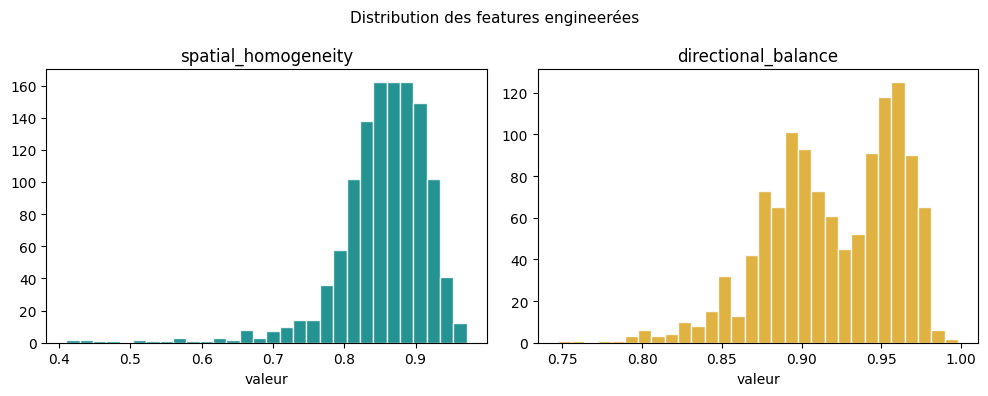

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, color in zip(axes,
                           ["spatial_homogeneity", "directional_balance"],
                           ["teal", "goldenrod"]):
    ax.hist(df_clipped[col], bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel("valeur")
fig.suptitle("Distribution des features engineerées", fontsize=11)
plt.tight_layout()
plt.savefig(COMMON_DIR / "03_engineered_features.png", dpi=100, bbox_inches="tight")
plt.show()

## 5. Matrice de features finale

On sélectionne les features pertinentes et on **inverse l'entropie**  
(haute entropie = désordre = mauvaise qualité → on veut que toutes les features pointent dans la même direction).

In [8]:
# Entropie inversée (basée sur le PIRE patch, pas la moyenne)
# → entropy_max capture les artefacts localisés qu'entropy_mean noierait
# ⚠ Anti-leakage : le max est calculé uniquement sur TRAIN
train_mask_clipped = df_clipped["split"] == "train"
entropy_max_train = df_clipped.loc[train_mask_clipped, "entropy_max"].max()
df_clipped["entropy_inv"] = entropy_max_train - df_clipped["entropy_max"]

# Features retenues pour le score composite
# rms_contrast_min : le patch le plus délavé dicte la note du contraste
FEATURE_COLS = [
    "laplacian_var_mean",
    "rms_contrast_min",     # pire patch (au lieu de _mean)
    "entropy_inv",          # inversée (basée sur entropy_max)
    "tenengrad_mean",
    "spatial_homogeneity",
    "directional_balance",
]

X_raw = df_clipped[FEATURE_COLS].values.astype(np.float32)
print(f"Matrice X : {X_raw.shape}  ({len(FEATURE_COLS)} features × {len(df_clipped)} images)")
print(f"Features  : {FEATURE_COLS}")
print(f"entropy_max (ref TRAIN) : {entropy_max_train:.4f}")

Matrice X : (1200, 6)  (6 features × 1200 images)
Features  : ['laplacian_var_mean', 'rms_contrast_min', 'entropy_inv', 'tenengrad_mean', 'spatial_homogeneity', 'directional_balance']
entropy_max (ref TRAIN) : 13.9932


In [9]:
# ⚠ Anti-leakage : indices/array TRAIN partagés par les méthodes A, B et C
train_idx = df_clipped["split"] == "train"
X_train = X_raw[train_idx.values]
print(f"Images TRAIN : {int(train_idx.sum())} / {len(df_clipped)}")

Images TRAIN : 1000 / 1200


## 6. Méthode B — Premier composant principal (PCA)

La PCA cherche la direction de **variance maximale** dans l'espace des features.
Si nos métriques sont cohérentes, le PC1 devrait correspondre à l'axe de qualité.

> **Attention au signe :** la PCA ne garantit pas que PC1 > 0 = bonne qualité.
> On vérifie la corrélation de PC1 avec le Tenengrad et on flip si nécessaire.

*(Calculée avant la Méthode A car les loadings de ce PC1 servent désormais de poids
objectifs pour la Méthode A — voir section 7.)*

In [10]:
# ⚠ Anti-leakage : StandardScaler et PCA fitted sur TRAIN uniquement
scaler_std = StandardScaler()
scaler_std.fit(X_train)                     # fit sur TRAIN seulement
X_std = scaler_std.transform(X_raw)         # transform sur tout le dataset

X_std_train = X_std[train_idx.values]

pca = PCA(n_components=min(6, X_std.shape[1]))
pca.fit(X_std_train)                        # fit sur TRAIN seulement

print(f"StandardScaler + PCA fitted sur {len(X_std_train)} images TRAIN")
print("Variance expliquée par composant :")
for i, r in enumerate(pca.explained_variance_ratio_):
    cumul = pca.explained_variance_ratio_[:i+1].sum()
    print(f"  PC{i+1} : {r*100:5.1f}%   (cumulé : {cumul*100:5.1f}%)")

StandardScaler + PCA fitted sur 1000 images TRAIN
Variance expliquée par composant :
  PC1 :  56.1%   (cumulé :  56.1%)
  PC2 :  22.1%   (cumulé :  78.2%)
  PC3 :  12.0%   (cumulé :  90.2%)
  PC4 :   5.9%   (cumulé :  96.0%)
  PC5 :   2.8%   (cumulé :  98.9%)
  PC6 :   1.1%   (cumulé : 100.0%)


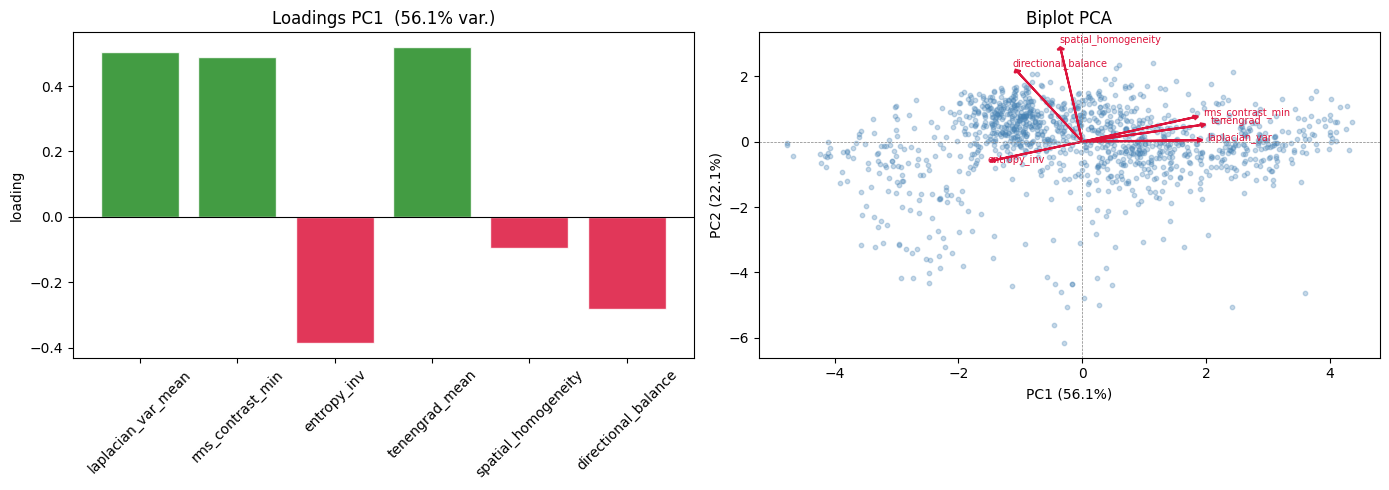

In [11]:
# Biplot : contribution de chaque feature au PC1 et PC2
components = pca.components_  # (n_components, n_features)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot des loadings PC1
colors_bar = ["forestgreen" if v > 0 else "crimson" for v in components[0]]
axes[0].bar(FEATURE_COLS, components[0], color=colors_bar, edgecolor="white", alpha=0.85)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title(f"Loadings PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
axes[0].set_ylabel("loading")
axes[0].tick_params(axis="x", rotation=45)

# Biplot PC1 vs PC2
coords = pca.transform(X_std)
axes[1].scatter(coords[:, 0], coords[:, 1], alpha=0.3, s=10, color="steelblue")
scale = np.abs(coords[:, :2]).max() * 0.6
for feat, (c1, c2) in zip(FEATURE_COLS, zip(components[0], components[1])):
    axes[1].arrow(0, 0, c1 * scale, c2 * scale,
                  head_width=scale*0.03, head_length=scale*0.02,
                  fc="crimson", ec="crimson", lw=1.5)
    axes[1].text(c1 * scale * 1.08, c2 * scale * 1.08,
                 feat.replace("_mean", ""), fontsize=7, color="crimson")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("Biplot PCA")
axes[1].axhline(0, color="grey", lw=0.5, ls="--")
axes[1].axvline(0, color="grey", lw=0.5, ls="--")

plt.tight_layout()
plt.savefig(APPROACH_B_DIR / "03_pca_biplot.png", dpi=120, bbox_inches="tight")
plt.show()

In [12]:
# Extraire PC1 et corriger son signe
pc1_raw = coords[:, 0]

# ⚠ Anti-leakage : corrélation vérifiée sur TRAIN uniquement
pc1_train = pc1_raw[train_idx.values]
corr_with_tenengrad = np.corrcoef(pc1_train, df_clipped.loc[train_idx, "tenengrad_mean"].values)[0, 1]
print(f"Corrélation PC1 ↔ tenengrad_mean (TRAIN) : {corr_with_tenengrad:+.4f}")

if corr_with_tenengrad < 0:
    pc1_raw = -pc1_raw
    print("→ Signe de PC1 inversé pour que score élevé = bonne qualité")
else:
    print("→ Signe de PC1 correct")

# ⚠ Anti-leakage : Min-Max normalisé avec les bornes TRAIN
pc1_train_final = pc1_raw[train_idx.values]
pc1_min, pc1_max = pc1_train_final.min(), pc1_train_final.max()
score_B = (pc1_raw - pc1_min) / (pc1_max - pc1_min + EPS)

df_clipped["score_pca"] = score_B

print(f"Score PCA — min={score_B.min():.4f}  max={score_B.max():.4f}  mean={score_B.mean():.4f}")
print(f"(bornes Min-Max issues de TRAIN : [{pc1_min:.4f}, {pc1_max:.4f}])")

Corrélation PC1 ↔ tenengrad_mean (TRAIN) : +0.9517
→ Signe de PC1 correct
Score PCA — min=-0.0740  max=1.0000  mean=0.4833
(bornes Min-Max issues de TRAIN : [-4.1397, 4.3507])


## 7. Méthode A — Score pondéré (poids = loadings PCA)

Chaque feature est normalisée à [0, 1] via Min-Max, puis combinée avec des poids **objectifs**,
dérivés des loadings absolus du PC1 calculé en section 6 :

$$w_i = \frac{|\text{loading}_i|}{\sum_j |\text{loading}_j|}$$

Contrairement à une première version de ce score qui utilisait des poids choisis manuellement
(et donc difficilement défendables dans un papier de recherche), ces poids reflètent directement
la contribution de chaque feature à la direction de variance maximale du jeu de données TRAIN.

In [13]:
# Poids = loadings absolus du PC1 (fit sur TRAIN, section 6), normalisés à somme 1
abs_loadings_pc1 = np.abs(components[0])
pca_weights = abs_loadings_pc1 / abs_loadings_pc1.sum()

print("Poids dérivés des loadings PCA (Méthode A) :")
for feat, w in zip(FEATURE_COLS, pca_weights):
    print(f"  {feat:30s}  w={w:.4f}")
assert abs(pca_weights.sum() - 1.0) < 1e-6

# ⚠ Anti-leakage : MinMaxScaler fitted sur TRAIN uniquement, puis transform sur tout
scaler_minmax = MinMaxScaler()
scaler_minmax.fit(X_train)                  # fit sur TRAIN seulement
X_norm = scaler_minmax.transform(X_raw)     # transform sur tout le dataset

weight_vector = pca_weights.astype(np.float32)
score_A = (X_norm * weight_vector).sum(axis=1)  # (N,) dans [0,1]

df_clipped["score_weighted"] = score_A

print(f"\nMinMaxScaler fitted sur {int(train_idx.sum())} images TRAIN")
print(f"Score pondéré (poids PCA) — min={score_A.min():.4f}  max={score_A.max():.4f}  mean={score_A.mean():.4f}")

Poids dérivés des loadings PCA (Méthode A) :
  laplacian_var_mean              w=0.2222
  rms_contrast_min                w=0.2145
  entropy_inv                     w=0.1694
  tenengrad_mean                  w=0.2281
  spatial_homogeneity             w=0.0414
  directional_balance             w=0.1244

MinMaxScaler fitted sur 1000 images TRAIN
Score pondéré (poids PCA) — min=0.0925  max=0.7931  mean=0.4478


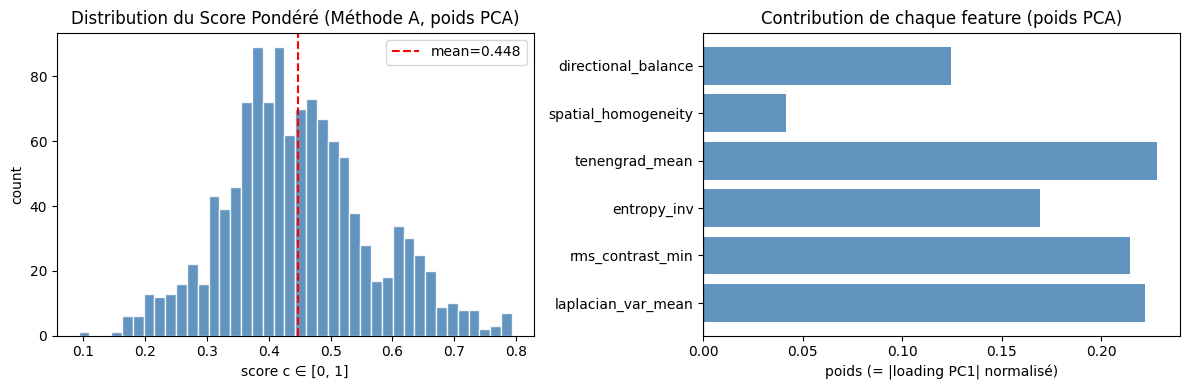

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(score_A, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_title("Distribution du Score Pondéré (Méthode A, poids PCA)")
axes[0].set_xlabel("score c ∈ [0, 1]")
axes[0].set_ylabel("count")
axes[0].axvline(score_A.mean(), color="red", lw=1.5, ls="--", label=f"mean={score_A.mean():.3f}")
axes[0].legend()

# Contribution de chaque feature (poids = loadings PCA)
axes[1].barh(FEATURE_COLS, weight_vector, color="steelblue", alpha=0.85)
axes[1].set_xlabel("poids (= |loading PC1| normalisé)")
axes[1].set_title("Contribution de chaque feature (poids PCA)")
axes[1].axvline(0, color="black", lw=0.8)

plt.tight_layout()
plt.savefig(APPROACH_A_DIR / "03_score_weighted.png", dpi=100, bbox_inches="tight")
plt.show()

## 8. Méthode A vs Méthode B — différence conceptuelle

Les deux méthodes utilisent la **même PCA** mais de façon différente :

| | Méthode A (pondéré) | Méthode B (PCA) |
|---|---|---|
| Normalisation par feature | Min-Max → [0,1] | Standardisation (z-score) |
| Combinaison | Somme pondérée (poids = \|loading PC1\|) | Projection PC1 (loadings signés, combinaison linéaire continue) |
| Interprétation | "Score de qualité physique", chaque feature contribue positivement | Direction de variance maximale, signe corrigé a posteriori |

Les deux scores sont donc corrélés (ils dérivent de la même PCA) mais pas identiques : A est une
moyenne pondérée toujours positive de features normalisées Min-Max, B est une combinaison linéaire
signée de features standardisées.

Corrélation Score A ↔ Score B : 0.8837


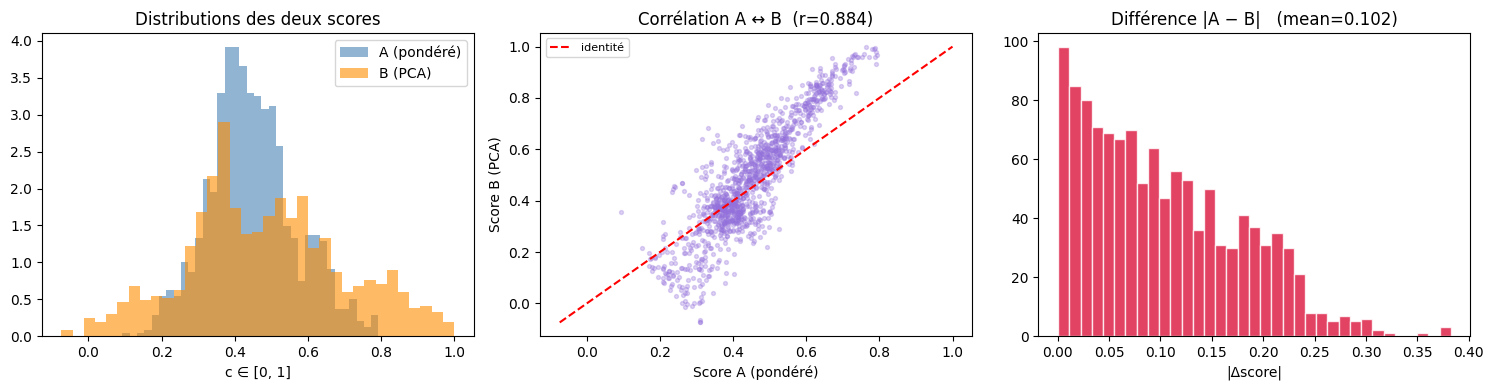

In [15]:
corr_AB = np.corrcoef(score_A, score_B)[0, 1]
print(f"Corrélation Score A ↔ Score B : {corr_AB:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distributions
axes[0].hist(score_A, bins=35, alpha=0.6, color="steelblue", label="A (pondéré)",  density=True)
axes[0].hist(score_B, bins=35, alpha=0.6, color="darkorange", label="B (PCA)",     density=True)
axes[0].set_title("Distributions des deux scores")
axes[0].set_xlabel("c ∈ [0, 1]")
axes[0].legend()

# Scatter A vs B
axes[1].scatter(score_A, score_B, alpha=0.3, s=8, color="mediumpurple")
lo, hi = min(score_A.min(), score_B.min()), max(score_A.max(), score_B.max())
axes[1].plot([lo, hi], [lo, hi], "r--", lw=1.5, label="identité")
axes[1].set_xlabel("Score A (pondéré)")
axes[1].set_ylabel("Score B (PCA)")
axes[1].set_title(f"Corrélation A ↔ B  (r={corr_AB:.3f})")
axes[1].legend(fontsize=8)

# Différence absolue
diff = np.abs(score_A - score_B)
axes[2].hist(diff, bins=35, color="crimson", edgecolor="white", alpha=0.8)
axes[2].set_title(f"Différence |A − B|   (mean={diff.mean():.3f})")
axes[2].set_xlabel("|Δscore|")

plt.tight_layout()
plt.savefig(COMMON_DIR / "03_score_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

In [16]:
# Images où les deux méthodes divergent le plus → cas ambigus
df_clipped["score_disagreement"] = diff
top_disagreement = df_clipped.nlargest(5, "score_disagreement")[["image_id", "score_weighted", "score_pca", "score_disagreement"]]
print("Images les plus ambiguës (désaccord A vs B) :")
print(top_disagreement.to_string(index=False))

Images les plus ambiguës (désaccord A vs B) :
 image_id  score_weighted  score_pca  score_disagreement
  val_145        0.308634  -0.074011            0.382645
  val_179        0.308337  -0.073367            0.381704
   val_77        0.309762  -0.062689            0.372450
train_871        0.330470   0.681680            0.351210
train_853        0.315467   0.640847            0.325380


## 9. Méthode C — Score appris (MLP + dégradations synthétiques sur features ResNet-18)

**Activée automatiquement si `APPROACH = "C"` dans `pipeline_config.py`.**

ARCADE ne fournit aucune annotation de qualité d'image réelle. On utilise donc une
**supervision par proxy** : on dégrade synthétiquement des images TRAIN propres avec une
sévérité connue (bruit gaussien, flou de mouvement, compression JPEG), et on entraîne un
petit MLP à prédire `1 - sévérité` à partir des features ResNet-18 (figées, mêmes features
que celles extraites dans le Notebook 2) de l'image dégradée.

**Important pour l'honnêteté scientifique :** la cible d'entraînement n'est *pas* une
annotation de qualité réelle — c'est un proxy basé sur des dégradations synthétiques
contrôlées. Le score résultant capture la capacité du MLP à reconnaître, dans l'espace de
représentation ResNet-18, des signatures de dégradation similaires à celles vues à
l'entraînement.

**Anti-leakage :** le MLP n'est entraîné que sur des dégradations d'images **TRAIN** (jamais
sur les images VAL réelles). Le split train/val interne au MLP est fait par image, jamais par
échantillon, pour ne pas mélanger plusieurs variantes dégradées de la même image entre les deux.

In [17]:
if USE_RESNET:
    if not (RESNET_NPY.exists() and RESNET_IDS_CSV.exists()):
        raise FileNotFoundError(
            f"Approche {APPROACH} requiert les features ResNet-18 mais les fichiers sont absents.\n"
            f"Relancez d'abord le Notebook 2 avec APPROACH = '{APPROACH}'."
        )

    DL_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device (Méthode C) : {DL_DEVICE}")

    # Même feature extractor que le Notebook 2 (ResNet-18 figé, ImageNet)
    _resnet_c = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
    resnet_feat_extractor_c = torch.nn.Sequential(*list(_resnet_c.children())[:-1]).to(DL_DEVICE).eval()
    _IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    _IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    def extract_resnet_feat_from_array(img01: np.ndarray) -> np.ndarray:
        """img01 : (H, W) float32 dans [0, 1] -> vecteur de features (512,)."""
        t = torch.from_numpy(img01.astype(np.float32)).unsqueeze(0).unsqueeze(0).expand(-1, 3, -1, -1)
        t = TVF.resize(t, [224, 224])
        t = (t - _IMAGENET_MEAN) / _IMAGENET_STD
        with torch.no_grad():
            feat = resnet_feat_extractor_c(t.to(DL_DEVICE))
        return feat.squeeze().cpu().numpy()

    print("Feature extractor ResNet-18 (Méthode C) prêt.")
else:
    print(f"Méthode C ignorée (approche {APPROACH})")

Méthode C ignorée (approche A)


In [18]:
if USE_RESNET:
    # ── Familles de dégradation synthétique (sévérité ∈ [0,1] -> paramètre physique) ──
    def deg_gaussian_noise(img, sigma):
        noisy = img + np.random.normal(0, sigma, img.shape)
        return np.clip(noisy, 0, 1).astype(np.float32)

    def deg_motion_blur(img, k):
        if k <= 1:
            return img.copy()
        kernel = np.ones((1, k), dtype=np.float32) / k
        return cv2.filter2D(img, -1, kernel)

    def deg_jpeg(img, quality):
        img_u8 = (img * 255).astype(np.uint8)
        _, enc = cv2.imencode(".jpg", img_u8, [int(cv2.IMWRITE_JPEG_QUALITY), int(quality)])
        dec = cv2.imdecode(enc, cv2.IMREAD_GRAYSCALE)
        return dec.astype(np.float32) / 255.0

    def apply_degradation(img: np.ndarray, family: str, severity: float) -> np.ndarray:
        """severity ∈ [0,1] : 0 = propre, 1 = pire dégradation de la famille."""
        if family == "noise":
            return deg_gaussian_noise(img, severity * 0.30)
        if family == "blur":
            k = int(round(1 + severity * 14))
            if k % 2 == 0:
                k += 1
            return deg_motion_blur(img, k)
        if family == "jpeg":
            quality = int(round(95 - severity * 80))
            return deg_jpeg(img, quality)
        raise ValueError(family)

    DL_FAMILIES = ["noise", "blur", "jpeg"]
    print("Familles de dégradation synthétique :", DL_FAMILIES)

In [19]:
if USE_RESNET:
    def _load_gray01(path) -> np.ndarray:
        return np.asarray(Image.open(path).convert("L"), dtype=np.float32) / 255.0

    DL_N_VARIANTS_PER_IMAGE = 3
    DL_SEED = 42
    rng = np.random.default_rng(DL_SEED)

    df_train_imgs = df_clipped.loc[train_idx].reset_index(drop=True)

    dl_feats, dl_targets, dl_img_ids = [], [], []
    for _, row in tqdm(df_train_imgs.iterrows(), total=len(df_train_imgs), desc="Synthèse + features (Méthode C)"):
        try:
            img = _load_gray01(row["path"])
        except Exception:
            continue

        # Version propre : sévérité = 0, cible = 1
        feat_clean = extract_resnet_feat_from_array(img)
        dl_feats.append(feat_clean); dl_targets.append(1.0); dl_img_ids.append(row["image_id"])

        for _ in range(DL_N_VARIANTS_PER_IMAGE):
            family = rng.choice(DL_FAMILIES)
            severity = float(rng.uniform(0.05, 1.0))
            img_deg = apply_degradation(img, family, severity)
            feat_deg = extract_resnet_feat_from_array(img_deg)
            dl_feats.append(feat_deg); dl_targets.append(1.0 - severity); dl_img_ids.append(row["image_id"])

    X_dl = np.stack(dl_feats).astype(np.float32)
    y_dl = np.array(dl_targets, dtype=np.float32)
    ids_dl = np.array(dl_img_ids)

    print(f"\nJeu synthétique (Méthode C) : {len(y_dl)} échantillons "
          f"({len(df_train_imgs)} images TRAIN × (1 propre + {DL_N_VARIANTS_PER_IMAGE} dégradées))")

In [20]:
if USE_RESNET:
    # Split synthétique train/val PAR IMAGE (jamais par échantillon), toujours à l'intérieur de TRAIN
    unique_train_ids = df_train_imgs["image_id"].unique().copy()
    rng.shuffle(unique_train_ids)
    n_val_ids = max(1, int(0.15 * len(unique_train_ids)))
    val_ids_dl = set(unique_train_ids[:n_val_ids])
    is_val_dl = np.array([iid in val_ids_dl for iid in ids_dl])

    X_tr, y_tr = X_dl[~is_val_dl], y_dl[~is_val_dl]
    X_va, y_va = X_dl[is_val_dl], y_dl[is_val_dl]
    print(f"Split synthétique : train={len(y_tr)}  val={len(y_va)} "
          f"({len(unique_train_ids) - n_val_ids} / {n_val_ids} images)")

    # Standardisation des features (fit sur train synthétique uniquement)
    scaler_dl = StandardScaler()
    scaler_dl.fit(X_tr)
    X_tr_s = scaler_dl.transform(X_tr)
    X_va_s = scaler_dl.transform(X_va)

In [21]:
if USE_RESNET:
    class QualityMLP(nn.Module):
        """512 (features ResNet-18) -> 128 -> 32 -> 1 (sigmoïde, score de qualité ∈ (0,1))."""
        def __init__(self, in_dim: int = 512):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, 128), nn.ReLU(),
                nn.Linear(128, 32), nn.ReLU(),
                nn.Linear(32, 1), nn.Sigmoid(),
            )

        def forward(self, x):
            return self.net(x).squeeze(-1)

    torch.manual_seed(DL_SEED)
    quality_mlp = QualityMLP(in_dim=X_tr_s.shape[1]).to(DL_DEVICE)
    optimizer_dl = torch.optim.Adam(quality_mlp.parameters(), lr=1e-3, weight_decay=1e-4)

    X_tr_t = torch.from_numpy(X_tr_s).float().to(DL_DEVICE)
    y_tr_t = torch.from_numpy(y_tr).float().to(DL_DEVICE)
    X_va_t = torch.from_numpy(X_va_s).float().to(DL_DEVICE)
    y_va_t = torch.from_numpy(y_va).float().to(DL_DEVICE)

    DL_N_EPOCHS = 200
    DL_BATCH = 64
    history_dl = {"train": [], "val": []}
    n_train_dl = X_tr_t.shape[0]

    for epoch in range(DL_N_EPOCHS):
        quality_mlp.train()
        perm = torch.randperm(n_train_dl)
        epoch_loss = 0.0
        for i in range(0, n_train_dl, DL_BATCH):
            idx = perm[i:i + DL_BATCH]
            xb, yb = X_tr_t[idx], y_tr_t[idx]
            pred = quality_mlp(xb)
            loss = F.mse_loss(pred, yb)
            optimizer_dl.zero_grad(set_to_none=True)
            loss.backward()
            optimizer_dl.step()
            epoch_loss += loss.item() * len(idx)
        epoch_loss /= n_train_dl

        quality_mlp.eval()
        with torch.no_grad():
            val_loss = F.mse_loss(quality_mlp(X_va_t), y_va_t).item()
        history_dl["train"].append(epoch_loss)
        history_dl["val"].append(val_loss)

    print(f"MLP (Méthode C) — MSE train final = {history_dl['train'][-1]:.5f}  "
          f"MSE val final = {history_dl['val'][-1]:.5f}")

In [22]:
if USE_RESNET:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(history_dl["train"], color="steelblue", label="train")
    axes[0].plot(history_dl["val"], color="darkorange", label="val")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("MSE")
    axes[0].set_title("Courbe d'entraînement du MLP (Méthode C)")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    quality_mlp.eval()
    with torch.no_grad():
        pred_va = quality_mlp(X_va_t).cpu().numpy()
    axes[1].scatter(y_va, pred_va, alpha=0.4, s=15, color="mediumpurple")
    axes[1].plot([0, 1], [0, 1], "r--", lw=1.5, label="identité")
    r_dl = np.corrcoef(y_va, pred_va)[0, 1]
    axes[1].set_xlabel("Cible connue (1 − sévérité synthétique)")
    axes[1].set_ylabel("Prédiction MLP")
    axes[1].set_title(f"Validation synthétique (r={r_dl:.3f})")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(APPROACH_C_DIR / "03_dl_training_curve.png", dpi=120, bbox_inches="tight")
    plt.show()

In [23]:
if USE_RESNET:
    # Sauvegarde du MLP appris (traçabilité / reproductibilité)
    torch.save({
        "model_state_dict": quality_mlp.state_dict(),
        "scaler_mean": scaler_dl.mean_,
        "scaler_scale": scaler_dl.scale_,
        "in_dim": X_tr_s.shape[1],
        "n_train_samples": int(n_train_dl),
        "val_mse": history_dl["val"][-1],
    }, APPROACH_C_DIR / "quality_mlp_resnet.pt")
    print(f"MLP sauvegardé → {APPROACH_C_DIR / 'quality_mlp_resnet.pt'}")

In [24]:
if USE_RESNET:
    # Application du MLP entraîné aux features ResNet-18 RÉELLES (toutes images, NB2)
    feat_arr = np.load(RESNET_NPY)                                  # (N_feat, 512)
    feat_ids = pd.read_csv(RESNET_IDS_CSV)["image_id"].tolist()     # N_feat

    feat_arr_std = scaler_dl.transform(feat_arr)
    quality_mlp.eval()
    with torch.no_grad():
        score_dl_raw_all = quality_mlp(torch.from_numpy(feat_arr_std).float().to(DL_DEVICE)).cpu().numpy()

    feat_ids_to_score = dict(zip(feat_ids, score_dl_raw_all))
    raw_scores = np.array([feat_ids_to_score.get(iid, np.nan) for iid in df_clipped["image_id"]])

    valid_mask = ~np.isnan(raw_scores)
    valid_train_mask = valid_mask & train_idx.values

    # ⚠ Anti-leakage : re-normalisation Min-Max avec les bornes TRAIN
    lo, hi = raw_scores[valid_train_mask].min(), raw_scores[valid_train_mask].max()
    score_dl = np.where(valid_mask, (raw_scores - lo) / (hi - lo + EPS), np.nan)
    df_clipped["score_dl"] = score_dl

    print(f"Score appris (Méthode C) — min={np.nanmin(score_dl):.4f}  "
          f"max={np.nanmax(score_dl):.4f}  mean={np.nanmean(score_dl):.4f}")
    print(f"Images sans feature ResNet (NaN) : {(~valid_mask).sum()}")
else:
    df_clipped["score_dl"] = np.nan

In [25]:
if USE_RESNET:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, other_col, other_label in zip(axes[:2], ["score_weighted", "score_pca"], ["A (pondéré, poids PCA)", "B (PCA)"]):
        mask = ~df_clipped["score_dl"].isna()
        ax.scatter(df_clipped.loc[mask, other_col], df_clipped.loc[mask, "score_dl"], alpha=0.25, s=10, color="teal")
        r = np.corrcoef(df_clipped.loc[mask, other_col], df_clipped.loc[mask, "score_dl"])[0, 1]
        ax.set_xlabel(f"Score {other_label}")
        ax.set_ylabel("Score C (appris)")
        ax.set_title(f"C vs {other_label.split(' ')[0]}  (r={r:.3f})")
        ax.grid(alpha=0.3)

    axes[2].hist(df_clipped["score_dl"].dropna(), bins=40, color="teal", edgecolor="white", alpha=0.85)
    axes[2].set_title("Distribution du Score Appris (Méthode C)")
    axes[2].set_xlabel("score c ∈ [0, 1]")

    fig.suptitle("Méthode C — Score appris vs A et B", fontsize=12)
    plt.tight_layout()
    plt.savefig(APPROACH_C_DIR / "03_dl_score_comparison.png", dpi=120, bbox_inches="tight")
    plt.show()

## 10. Sélection du score final selon l'approche

Le score utilisé comme `quality_score` est déterminé par `APPROACH` dans `pipeline_config.py`.

In [26]:
# Sélection du score basée sur APPROACH (défini dans pipeline_config.py)
FINAL_SCORE_COL = get_score_column()

# Vérifier que la colonne existe
if FINAL_SCORE_COL not in df_clipped.columns:
    available = [c for c in df_clipped.columns if c.startswith("score_")]
    raise ValueError(
        f"Approche '{APPROACH}' requiert la colonne '{FINAL_SCORE_COL}' "
        f"mais elle n'existe pas.\nColonnes disponibles : {available}"
    )

# Vérifier que les valeurs ne sont pas toutes NaN (cas de score_hybrid sans ResNet)
if df_clipped[FINAL_SCORE_COL].isna().all():
    raise ValueError(
        f"La colonne '{FINAL_SCORE_COL}' (approche {APPROACH}) ne contient que des NaN. "
        f"Vérifiez que les données nécessaires sont disponibles."
    )

df_clipped["quality_score"] = df_clipped[FINAL_SCORE_COL]

approach_cfg = get_approach_config()
print(f"Approche sélectionnée : {APPROACH} — {approach_cfg['name']}")
print(f"Colonne utilisée     : {FINAL_SCORE_COL}")
print(f"Score — min={df_clipped['quality_score'].min():.4f}  "
      f"max={df_clipped['quality_score'].max():.4f}  "
      f"mean={df_clipped['quality_score'].mean():.4f}")

Approche sélectionnée : A — Score pondéré (poids PCA)
Colonne utilisée     : score_weighted
Score — min=0.0925  max=0.7931  mean=0.4478


## 11. Validation visuelle — galerie triée par score

C'est la figure de validation clé : elle prouve que notre score est cohérent avec la qualité visuelle.

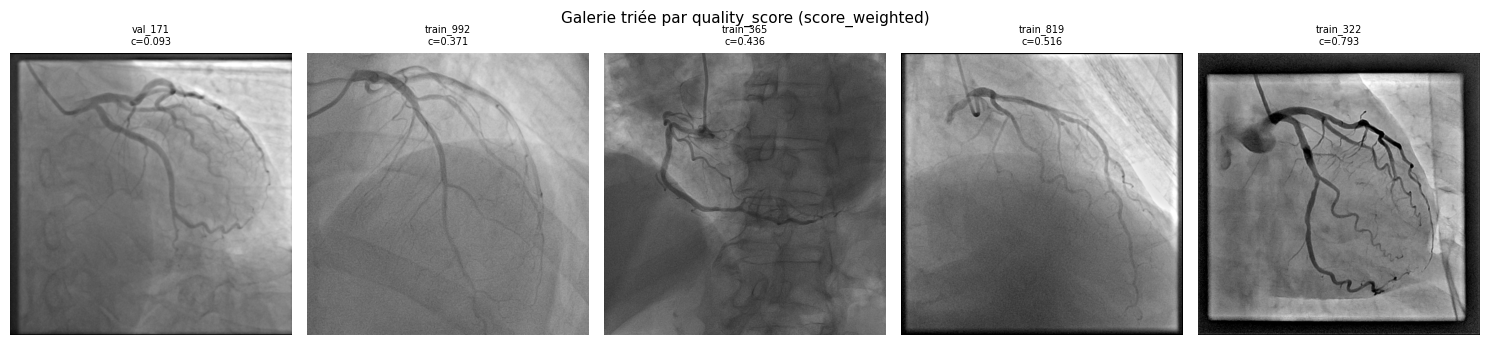

In [27]:
def load_gray(path) -> np.ndarray:
    return np.asarray(Image.open(path).convert("L"), dtype=np.float32) / 255.0


df_sorted = df_clipped.sort_values("quality_score").reset_index(drop=True)

# Sélectionner 5 images dans chaque quintile
N_COL  = 5
n_imgs = len(df_sorted)
quintile_indices = np.linspace(0, n_imgs - 1, N_COL, dtype=int)

fig, axes = plt.subplots(1, N_COL, figsize=(3 * N_COL, 3.5))

for col, idx in enumerate(quintile_indices):
    row_data = df_sorted.iloc[idx]
    try:
        img = load_gray(row_data["path"])
    except Exception:
        img = np.zeros((64, 64))
    axes[col].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes[col].set_title(
        f"{str(row_data['image_id'])[:12]}\nc={row_data['quality_score']:.3f}",
        fontsize=7
    )
    axes[col].axis("off")

fig.suptitle(f"Galerie triée par quality_score ({FINAL_SCORE_COL})", fontsize=11)
plt.tight_layout()
plt.savefig(CURRENT_APPROACH_DIR / "03_gallery_sorted_by_score.png", dpi=120, bbox_inches="tight")
plt.show()

In [28]:
# Validation quantitative : corrélation du score final avec chaque métrique
print("Corrélation du score final avec les métriques brutes :")
for col in MEAN_COLS + ["spatial_homogeneity", "directional_balance"]:
    r = np.corrcoef(df_clipped["quality_score"].values,
                    df_clipped[col].values)[0, 1]
    bar = "▓" * int(abs(r) * 20)
    sign = "+" if r > 0 else "-"
    print(f"  {col:30s}  r={r:+.4f}  {sign}{bar}")

Corrélation du score final avec les métriques brutes :
  laplacian_var_mean              r=+0.9124  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  rms_contrast_mean               r=+0.8573  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  entropy_mean                    r=+0.1868  +▓▓▓
  tenengrad_mean                  r=+0.9366  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  ten_H_mean                      r=+0.9326  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  ten_V_mean                      r=+0.9147  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  ten_D1_mean                     r=+0.9296  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  ten_D2_mean                     r=+0.9373  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  spatial_homogeneity             r=+0.1180  +▓▓
  directional_balance             r=-0.2309  -▓▓▓▓


## 12. Seuillage en labels catégoriels

On divise le score en **3 classes** (tertiles) pour :
- La visualisation dans les notebooks suivants
- L'évaluation de robustesse du Notebook 5 (test sur les images "bad")

| Label | Tertile | Signification |
|---|---|---|
| `bad` | [0, 33%[ | Images avec artefacts sévères |
| `medium` | [33%, 67%[ | Qualité acceptable |
| `good` | [67%, 100%] | Images cliniquement exploitables |

In [29]:
# ⚠ Anti-leakage : seuils de tertiles calculés sur TRAIN uniquement
train_scores = df_clipped.loc[train_idx, "quality_score"]
t33 = train_scores.quantile(1/3)
t67 = train_scores.quantile(2/3)

def assign_label(score: float) -> str:
    if score < t33:
        return "bad"
    elif score < t67:
        return "medium"
    return "good"

df_clipped["quality_label"] = df_clipped["quality_score"].apply(assign_label)

print(f"Seuils (calculés sur TRAIN) : bad < {t33:.4f} ≤ medium < {t67:.4f} ≤ good")
print("\nDistribution des labels (tout le dataset) :")
print(df_clipped["quality_label"].value_counts().to_string())
print("\nDistribution par split :")
print(df_clipped.groupby("split")["quality_label"].value_counts().unstack(fill_value=0))

Seuils (calculés sur TRAIN) : bad < 0.3874 ≤ medium < 0.4903 ≤ good

Distribution des labels (tout le dataset) :
quality_label
medium    422
good      395
bad       383

Distribution par split :
quality_label  bad  good  medium
split                           
train          333   334     333
val             50    61      89


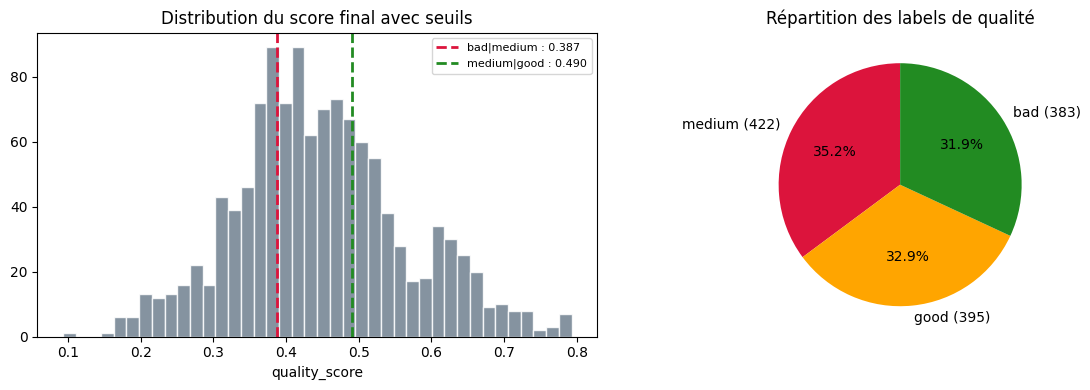

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution du score avec seuils
axes[0].hist(df_clipped["quality_score"], bins=40, color="slategray", edgecolor="white", alpha=0.85)
axes[0].axvline(t33, color="crimson",     lw=2, ls="--", label=f"bad|medium : {t33:.3f}")
axes[0].axvline(t67, color="forestgreen", lw=2, ls="--", label=f"medium|good : {t67:.3f}")
axes[0].set_title("Distribution du score final avec seuils")
axes[0].set_xlabel("quality_score")
axes[0].legend(fontsize=8)

# Camembert des labels
counts = df_clipped["quality_label"].value_counts()
axes[1].pie(
    counts.values,
    labels=[f"{l} ({n})" for l, n in counts.items()],
    colors=["crimson", "orange", "forestgreen"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[1].set_title("Répartition des labels de qualité")

plt.tight_layout()
plt.savefig(CURRENT_APPROACH_DIR / "03_label_distribution.png", dpi=100, bbox_inches="tight")
plt.show()

## 13. Galerie good / bad / medium (9 exemples)

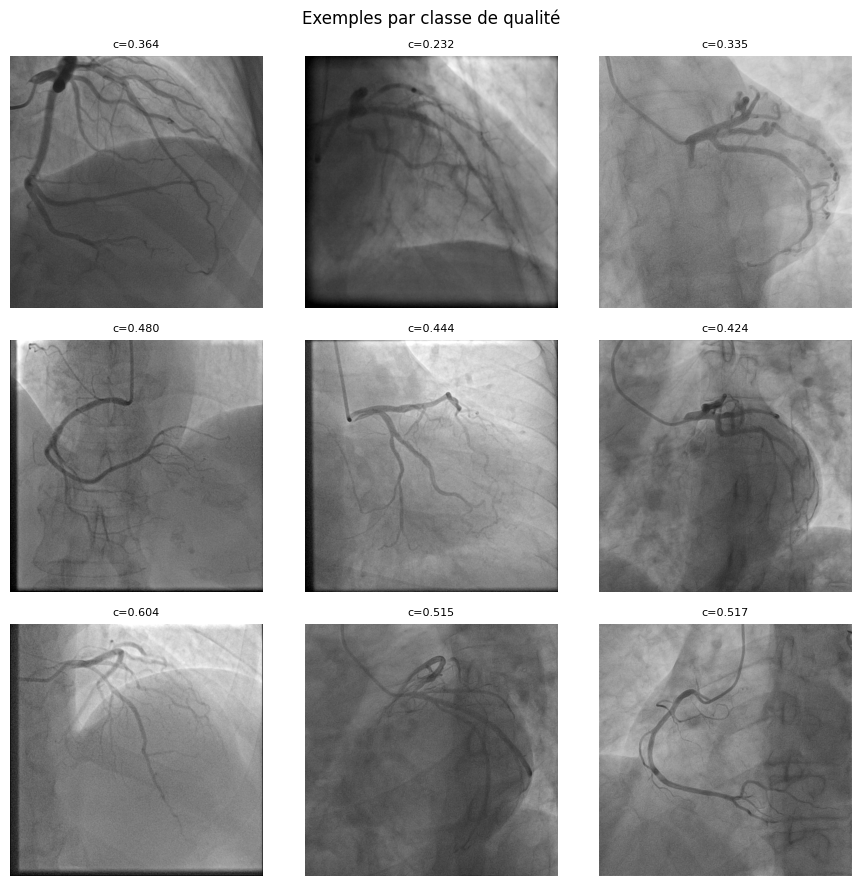

In [31]:
import random
random.seed(0)

N_PER_CLASS = 3
label_order = ["bad", "medium", "good"]
label_colors = {"bad": "crimson", "medium": "darkorange", "good": "forestgreen"}

fig, axes = plt.subplots(len(label_order), N_PER_CLASS, figsize=(3 * N_PER_CLASS, 3 * len(label_order)))

for row, label in enumerate(label_order):
    subset = df_clipped[df_clipped["quality_label"] == label]
    sample = subset.sample(min(N_PER_CLASS, len(subset)), random_state=row)
    for col, (_, r) in enumerate(sample.iterrows()):
        ax = axes[row, col]
        try:
            img = load_gray(r["path"])
        except Exception:
            img = np.zeros((64, 64))
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"c={r['quality_score']:.3f}", fontsize=8)
        if col == 0:
            ax.set_ylabel(label.upper(), color=label_colors[label], fontsize=10, fontweight="bold")
        ax.axis("off")

fig.suptitle("Exemples par classe de qualité", fontsize=12)
plt.tight_layout()
plt.savefig(CURRENT_APPROACH_DIR / "03_examples_per_class.png", dpi=120, bbox_inches="tight")
plt.show()

## 14. Export — `labels_quality.csv`

Ce fichier est le **pont entre ce travail et le Notebook 4** (modification de l'architecture MedVAE).

In [32]:
export_cols = [
    "image_id",
    "path",
    "split",
    "quality_score",
    "quality_label",
    "score_weighted",
    "score_pca",
]
if USE_RESNET:
    export_cols += ["score_dl"]

df_export = df_clipped[export_cols].copy()

# Fusionner avec un éventuel labels_quality.csv déjà écrit par une autre approche
# (A/B/C tournent dans des passages séparés) : on ne veut jamais perdre une colonne
# score_* déjà calculée précédemment (ex: score_dl si APPROACH=C n'est pas le dernier
# lancé) — NB07 a besoin des 3 colonnes simultanément.
if OUT_LABELS_CSV.exists():
    df_prev = pd.read_csv(OUT_LABELS_CSV)
    prev_score_cols = [c for c in df_prev.columns
                        if c.startswith("score_") and c not in df_export.columns]
    if prev_score_cols:
        df_export = df_export.merge(df_prev[["image_id"] + prev_score_cols], on="image_id", how="left")
        print(f"Colonnes récupérées d'un run précédent : {prev_score_cols}")

df_export.to_csv(OUT_LABELS_CSV, index=False)

# Copie figée dans le dossier de l'approche active : contrairement à OUT_LABELS_CSV
# (partagé, écrasé par chaque run), ce fichier garde quality_score/quality_label
# tels que produits par CETTE approche, même après que A/B/C aient toutes tourné.
df_export.to_csv(OUT_LABELS_CSV_APPROACH, index=False)

print(f"Sauvegardé → {OUT_LABELS_CSV}")
print(f"Sauvegardé (copie figée approche {APPROACH}) → {OUT_LABELS_CSV_APPROACH}")
print(f"Lignes     : {len(df_export)}  (train={int((df_export['split']=='train').sum())}, val={int((df_export['split']=='val').sum())})")
print(f"Colonnes   : {list(df_export.columns)}")
df_export.head(5)

Colonnes récupérées d'un run précédent : ['score_dl']
Sauvegardé → outputs_theophile/03_Inductive_Bias_Generation/labels_quality.csv
Sauvegardé (copie figée approche A) → outputs_theophile/03_Inductive_Bias_Generation/approach_A_weighted_pca/labels_quality.csv
Lignes     : 1200  (train=1000, val=200)
Colonnes   : ['image_id', 'path', 'split', 'quality_score', 'quality_label', 'score_weighted', 'score_pca', 'score_dl']


,image_id,path,split,quality_score,quality_label,score_weighted,score_pca,score_dl
0,train_1,/home/infres/yrothlin-24/arcade_challenge_data...,train,0.470286,medium,0.470286,0.477749,0.875778
1,train_10,/home/infres/yrothlin-24/arcade_challenge_data...,train,0.494742,good,0.494742,0.333257,0.868982
2,train_100,/home/infres/yrothlin-24/arcade_challenge_data...,train,0.464330,medium,0.464330,0.518073,0.551897
3,train_1000,/home/infres/yrothlin-24/arcade_challenge_data...,train,0.639596,good,0.639596,0.795698,0.982733
4,train_101,/home/infres/yrothlin-24/arcade_challenge_data...,train,0.505990,good,0.505990,0.522800,0.986422


In [33]:
# Vérification finale : statistiques par label
print("Statistiques du quality_score par label :")
print(df_export.groupby("quality_label")["quality_score"].describe().round(4).to_string())

Statistiques du quality_score par label :
               count    mean     std     min     25%     50%     75%     max
quality_label                                                               
bad            383.0  0.3223  0.0567  0.0925  0.2920  0.3391  0.3684  0.3872
good           395.0  0.5808  0.0741  0.4903  0.5171  0.5614  0.6312  0.7931
medium         422.0  0.4372  0.0293  0.3874  0.4113  0.4356  0.4634  0.4902


## Résumé du Notebook 3

| Étape | Résultat |
|---|---|
| Feature engineering | `spatial_homogeneity` + `directional_balance` |
| Méthode B (calculée en premier) | PC1 normalisé (objectif, data-driven) |
| Méthode A | Score pondéré ∈ [0, 1], poids = loadings PCA |
| Méthode C | Score appris — MLP sur features ResNet-18, supervision par dégradations synthétiques |
| Score final retenu | Selon `APPROACH` dans `pipeline_config.py` |
| Labels catégoriels | `bad` / `medium` / `good` (tertiles, calculés sur TRAIN) |
| Export | `labels_quality.csv` (contient `score_weighted`, `score_pca`, `score_dl` si calculé) |

**Prochain notebook :** `04_MedVAE_Architecture_Mod.ipynb` —
Modifier le DataLoader et l'encodeur/décodeur MedVAE pour conditionner la génération sur `quality_score`.